# Avellaneda-Stoikov Strategy

## Lighter backtesting

In [1]:
import sys
import math
import numpy as np
from pathlib import Path
import os
import itertools
from tqdm.notebook import tqdm

# Корень репо = ближайший предок cwd с .git. Кладём на путь и его (для backtesting),
# и research/ (для tools) — до импортов ниже.
here = Path.cwd().resolve()
ROOT = next(p for p in (here, *here.parents) if (p / ".git").exists())
for path in (str(ROOT), str(ROOT / "research")):
    if path not in sys.path:
        sys.path.insert(0, path)

from tools import ROOT   # переопределяет ROOT корректным путём из tools/__init__.py
from backtesting.lighter import Strategy, Backtester, OrderBook, LighterFeed
from backtesting.lighter.instruments.visualize import BacktestResult

CAPITAL = 2000.0  # USD

In [2]:
import pandas as pd

os.makedirs("results", exist_ok=True)


def grid_search(strategy_cls, param_grid, backtester, feed, fixed_params=None, **_):
    """Exhaustive grid search; returns DataFrame sorted by sharpe_annualized."""
    fixed_params = fixed_params or {}
    keys         = list(param_grid.keys())
    combos       = list(itertools.product(*param_grid.values()))
    results      = []

    for combo in tqdm(combos, desc="grid_search"):
        params = dict(zip(keys, combo)) | fixed_params
        prefix = f"/tmp/_gs_{abs(hash(str(sorted(params.items()))))}"
        backtester.run(strategy_cls(**params), feed, output_path=prefix)

        s   = BacktestResult(prefix, capital=CAPITAL).summary()
        row = dict(params)
        row["total_pnl"]         = s["total_pnl"]
        row["sharpe_annualized"] = s["sharpe_annualized"]
        row["n_fills"]           = s["n_fills"]
        row["n_bid_fills"]       = s["n_bid_fills"]
        row["n_ask_fills"]       = s["n_ask_fills"]
        row["max_abs_inventory"] = s["max_abs_inventory"]
        row["turnover_usd"]      = s["turnover_usd"]
        results.append(row)

        for suffix in ("_pnl", "_quotes", "_fills"):
            try: os.remove(f"{prefix}{suffix}.csv")
            except: pass

    return pd.DataFrame(results)

In [3]:
class AvellanedaStoikov(Strategy):
    def __init__(self, sigma, kappa, gamma, T, Q):
        self.gamma   = gamma
        self.T       = T
        self._sigma2 = sigma ** 2
        self.Q = Q
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us  = None

    def on_lob(self, ob: OrderBook, inventory: float):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))

        risk_term   = self.gamma * self._sigma2 * tau
        r           = ob.mid - inventory * risk_term
        half_spread = 0.5 * risk_term + self._half_log_term
        return [
            ("bid", r - half_spread, self.Q),
            ("ask", r + half_spread, self.Q),
        ]

In [4]:
days = range(13, 15)          # 14, 15, 16, 17 июля
hours = range(0, 24)

lob_paths = []
trades_paths = []

for d in days:
    day_str = f"202607{d:02d}"
    for h in hours:
        lob_paths.append(ROOT / f"data/lighter/TAO/lob/{day_str}/{h:02d}.parquet")
        trades_paths.append(ROOT / f"data/lighter/TAO/trades/{day_str}/{h:02d}.jsonl.zst")

print(f"Всего файлов LOB: {len(lob_paths)}")
print(f"Всего файлов trades: {len(trades_paths)}")

Всего файлов LOB: 48
Всего файлов trades: 48


In [5]:
feed = LighterFeed(lob_paths, trades_paths)
feed

LighterFeed(lob=1,383,938 snapshots [2026-07-13 00:00:00.043000 → 2026-07-14 23:59:59.916000], trades=4,620 [2026-07-12 23:10:32.212000 → 2026-07-14 23:57:30.586000])

In [6]:
# Calibrate AS inputs straight from the loaded feed (arrays, not CSV).
mid    = (feed.bid_px[:, 0] + feed.ask_px[:, 0]) / 2.0
mid_ts = pd.to_datetime(feed.lob_ts, unit="us")
tr_ts  = pd.to_datetime(feed.trade_ts, unit="us")

# sigma — std of 1-sec mid increments (price / sqrt-sec)
mid_1s    = pd.Series(mid, index=mid_ts).resample("1s").last().ffill()
sigma_hat = float(mid_1s.diff().dropna().std())

# A — mean trade arrival rate (trades / sec)
span_sec = (tr_ts.max() - tr_ts.min()).total_seconds()
A_hat    = len(feed.trade_ts) / span_sec

# kappa — exp decay from mean |trade_price - mid|; mid aligned to each trade (backward)
aligned = pd.merge_asof(
    pd.DataFrame({"price": feed.trade_price}, index=tr_ts).sort_index(),
    pd.DataFrame({"mid": mid}, index=mid_ts).sort_index(),
    left_index=True, right_index=True, direction="backward",
).dropna()
delta     = (aligned["price"] - aligned["mid"]).abs()
kappa_hat = 1.0 / float(delta[delta > 0].mean())

print(f"sigma = {sigma_hat:.3e}   (mid volatility, price / sqrt-sec)")
print(f"A     = {A_hat:.5f}   (mean trade arrival rate, trades/sec)")
print(f"kappa = {kappa_hat:.3e}   (exp decay rate; mean |trade - mid| = {1/kappa_hat:.3e})")

sigma = 2.345e-02   (mid volatility, price / sqrt-sec)
A     = 0.02631   (mean trade arrival rate, trades/sec)
kappa = 1.980e+01   (exp decay rate; mean |trade - mid| = 5.051e-02)


In [7]:
def check_feed(f):
    assert f.lob_ts.dtype == np.int64 and f.trade_ts.dtype == np.int64
    assert f.bid_px.shape[1] == f.ask_px.shape[1], "level count mismatch"
    assert (np.diff(f.lob_ts)   >= 0).all(), "LOB timestamps not sorted"
    assert (np.diff(f.trade_ts) >= 0).all(), "trade timestamps not sorted"
    assert set(np.unique(f.trade_is_sell)).issubset({0, 1})

    best_bid, best_ask = f.bid_px[:, 0], f.ask_px[:, 0]
    crossed = int((best_ask <= best_bid).sum())
    print(f"levels        : {f.bid_px.shape[1]}")
    print(f"lob snapshots : {len(f.lob_ts):,}  (crossed/locked: {crossed})")
    print(f"trades        : {len(f.trade_ts):,}  (sells: {int(f.trade_is_sell.sum()):,})")
    print("invariants OK")

check_feed(feed)

levels        : 30
lob snapshots : 1,383,938  (crossed/locked: 0)
trades        : 4,620  (sells: 2,207)
invariants OK


In [8]:
bt = Backtester(log_interval_sec=10.0)

sweep = grid_search(
    AvellanedaStoikov,
    {
        "sigma": [2.355e-2],
        "kappa": [2.306e+1],
        "gamma": [0.02, 0.05, 0.1, 0.2],
        "T":     [600.0, 1000.0, 5000, 14000],
        "Q":     [0.001, 0.01, 0.1, 1, 2, 5],
    },
    bt,
    feed,
)
sweep.sort_values("sharpe_annualized", ascending=False)[
    ["sigma", "kappa", "gamma", "total_pnl",
     "sharpe_annualized", "max_abs_inventory", "n_fills", "turnover_usd"]
].head(15)

grid_search:   0%|          | 0/96 [00:00<?, ?it/s]

,sigma,kappa,gamma,total_pnl,sharpe_annualized,max_abs_inventory,n_fills,turnover_usd
2,0.02355,23.06,0.02,25.298880,11.731199,7.468,1268,21044.535307
8,0.02355,23.06,0.02,18.886518,10.788350,6.047,1240,20746.515106
50,0.02355,23.06,0.10,7.669663,10.370575,3.469,900,14957.676368
26,0.02355,23.06,0.05,12.615540,10.067939,5.507,1087,18004.899171
74,0.02355,23.06,0.20,4.360167,9.604285,3.016,680,11505.287361
79,0.02355,23.06,0.20,1.383644,9.354501,0.500,646,1237.991655
80,0.02355,23.06,0.20,3.638007,9.167454,3.498,646,11111.041812
55,0.02355,23.06,0.10,1.790165,8.245687,0.659,910,1738.887912
4,0.02355,23.06,0.02,27.163292,7.577519,20.286,1309,157696.244226
32,0.02355,23.06,0.05,7.319246,7.532729,5.185,1090,18257.312006


In [9]:
best = sweep.sort_values("sharpe_annualized", ascending=False).iloc[0]
best_params = {k: best[k] for k in ["sigma", "kappa", "gamma", "T", "Q"]}
print("Best params:", best_params)

Best params: {'sigma': np.float64(0.02355), 'kappa': np.float64(23.06), 'gamma': np.float64(0.02), 'T': np.float64(600.0), 'Q': np.float64(0.1)}


In [10]:
params = best_params
# params = {'sigma': np.float64(0.02355), 'kappa': np.float64(23.06), 'gamma': np.float64(0.2), 'T': np.float64(14000.0), 'Q': np.float64(0.001)}
prefix = "/tmp/_lighter_dod"

bt = Backtester(log_interval_sec=10.0)
bt.run(AvellanedaStoikov(**params), feed=feed, output_path=prefix)

'/tmp/_lighter_dod'

In [11]:
s = BacktestResult(prefix, capital=CAPITAL)
display(s.summary_df())

value
group     metric                      
PnL       total_pnl ($)       +25.2989
          total_pnl (%)       +1.2649%
          sharpe_annualized     +11.73
          max_drawdown ($)    -18.6830
          max_drawdown (%)    -0.9342%
Fills     n_fills                1,268
          n_bid_fills              672
          n_ask_fills              596
          fill_imbalance       +0.0599
Inventory avg_inventory        -0.8395
          std_inventory         2.9721
          max_abs_inventory     7.4680
          turnover ($)       21,044.54

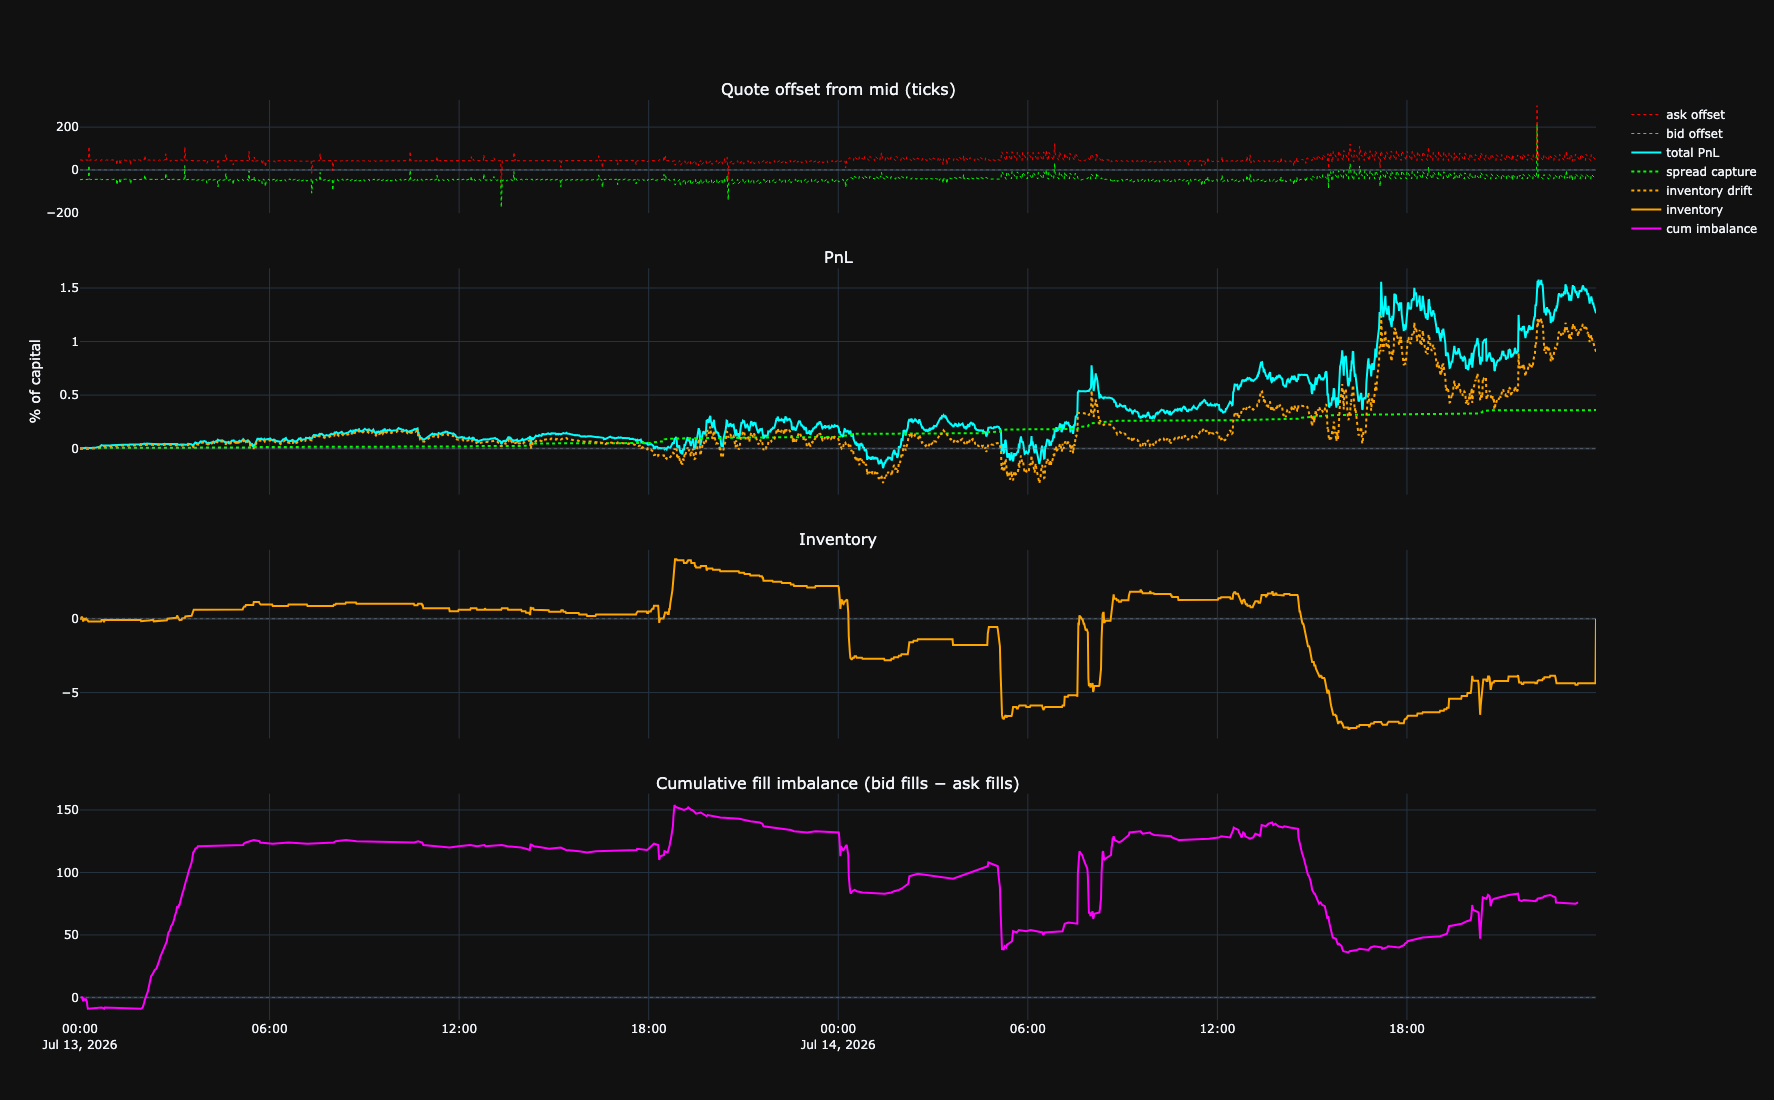

In [13]:
s.plot(tick_size=1e-3).show()